In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

2026-02-28 17:09:48.042766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772298588.293867      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772298588.358139      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772298588.878349      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772298588.878391      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772298588.878393      55 computation_placer.cc:177] computation placer alr

In [7]:
SPLIT_RATIO = 0.8   # change this in each notebook
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

In [8]:
train_path = "/kaggle/input/datasets/redwanahmed2025/alzheimer-dataset/Alzheimer Dataset/train"
test_path  = "/kaggle/input/datasets/redwanahmed2025/alzheimer-dataset/Alzheimer Dataset/test"

all_images = []
all_labels = []

for base_path in [train_path, test_path]:
    for class_name in os.listdir(base_path):
        class_path = os.path.join(base_path, class_name)
        for img in os.listdir(class_path):
            all_images.append(os.path.join(class_path, img))
            all_labels.append(class_name)

df = pd.DataFrame({
    "filepath": all_images,
    "label": all_labels
})

print("Total samples:", len(df))
print(df["label"].value_counts())

Total samples: 5154
label
MCI    2590
CN     1440
AD     1124
Name: count, dtype: int64


In [9]:
train_df, test_df = train_test_split(
    df,
    train_size=SPLIT_RATIO,
    stratify=df["label"],
    random_state=42
)

# Now create validation (10% of training)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 3710
Val: 413
Test: 1031


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, label

def create_dataset(df):
    paths = df["filepath"].values
    labels = pd.Categorical(df["label"]).codes
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = create_dataset(train_df)
val_ds   = create_dataset(val_df)
test_ds  = create_dataset(test_df)

In [15]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.5286361763494025), 1: np.float64(1.1925425908068146), 2: np.float64(0.663447782546495)}


In [16]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # first stage

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

training_time = time.time() - start_time
print("Training time (seconds):", training_time)

Epoch 1/50


I0000 00:00:1772299270.047451     132 service.cc:152] XLA service 0x7ef26c011ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772299270.047490     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772299270.047494     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772299271.203076     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-28 17:21:19.247679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:21:19.383916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1772299281.395664     132 device_co

115/116 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3296 - loss: 1.2702

2026-02-28 17:21:37.018301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:21:37.154589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.3297 - loss: 1.2699

2026-02-28 17:21:51.606752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 17:21:51.744384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


116/116 ━━━━━━━━━━━━━━━━━━━━ 48s 277ms/step - accuracy: 0.3298 - loss: 1.2696 - val_accuracy: 0.3462 - val_loss: 1.1113
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3490 - loss: 1.2022 - val_accuracy: 0.4140 - val_loss: 1.0690
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3721 - loss: 1.1436 - val_accuracy: 0.4867 - val_loss: 1.0407
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4002 - loss: 1.1193 - val_accuracy: 0.4697 - val_loss: 1.0244
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4125 - loss: 1.0966 - val_accuracy: 0.4746 - val_loss: 1.0098
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4395 - loss: 1.0679 - val_accuracy: 0.5496 - val_loss: 0.9730
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4555 - loss: 1.0503 - val_accuracy: 0.5593 - val_loss: 0.9610
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4648 - loss: 1.0112 - val_accuracy: 0.5

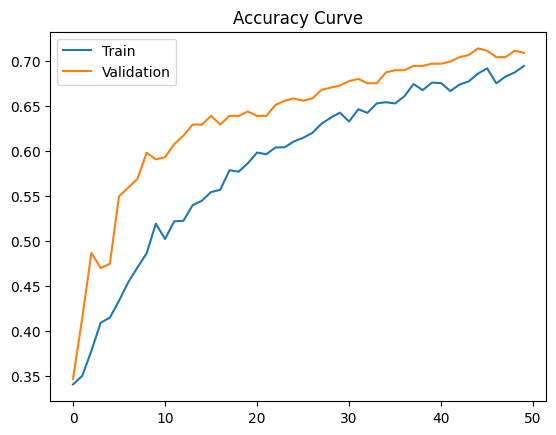

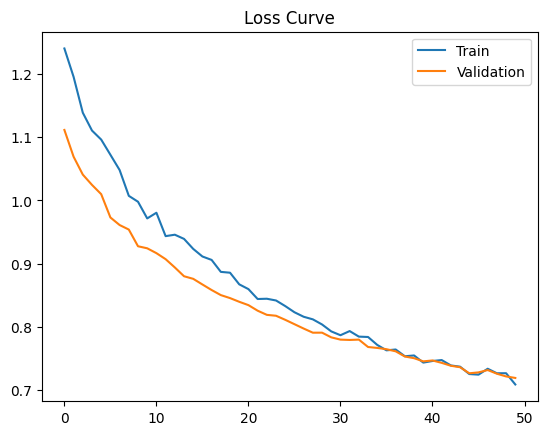

In [19]:
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy Curve")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss Curve")
plt.legend(["Train", "Validation"])
plt.show()

In [21]:
start_test = time.time()

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

testing_time = time.time() - start_test

print("Testing time:", testing_time)
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━

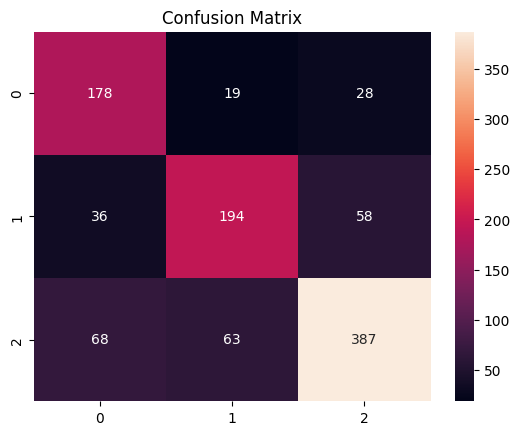

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [23]:
y_true_bin = label_binarize(y_true, classes=[0,1,2])
auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr")

print("ROC-AUC:", auc)

ROC-AUC: 0.8874100609046732


In [24]:
concrete_func = tf.function(lambda x: model(x))
concrete_func = concrete_func.get_concrete_function(
    tf.TensorSpec([1, 224, 224, 3], tf.float32)
)

from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph_def = frozen_func.graph.as_graph_def()

print("Approximate MobileNetV2 GFLOPs at 224x224 ≈ 0.3 GFLOPs")

I0000 00:00:1772300084.244253      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1772300084.244462      55 single_machine.cc:374] Starting new session
I0000 00:00:1772300084.257860      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772300084.259431      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Approximate MobileNetV2 GFLOPs at 224x224 ≈ 0.3 GFLOPs
